Dataset already exists at: /home/tiamheydari/Desktop/Tiam AI/Workshop Notebooks/Workshop_CNNs/data/tree1d_vertical
Dataset folder       : /home/tiamheydari/Desktop/Tiam AI/Workshop Notebooks/Workshop_CNNs/data/tree1d_vertical
x_img shape          : torch.Size([16, 1, 50, 1])
target_map_img shape : torch.Size([16, 1, 50, 1])
target_map shape     : torch.Size([16, 50])
center_index shape   : torch.Size([16])


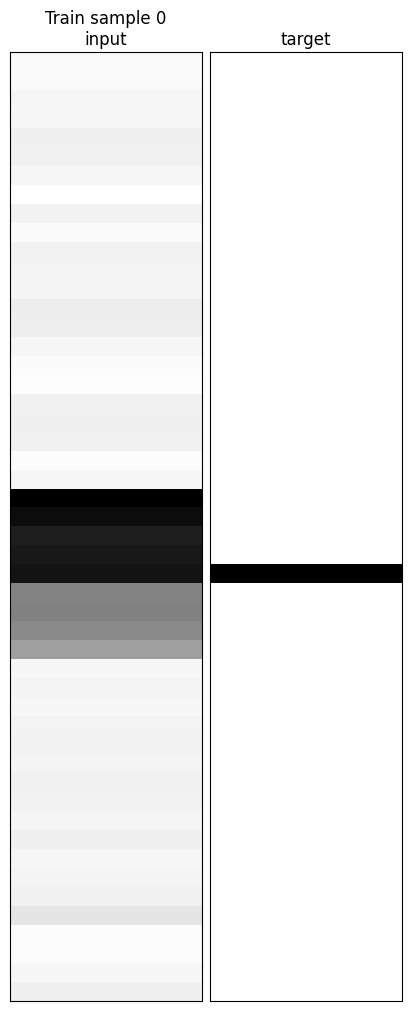

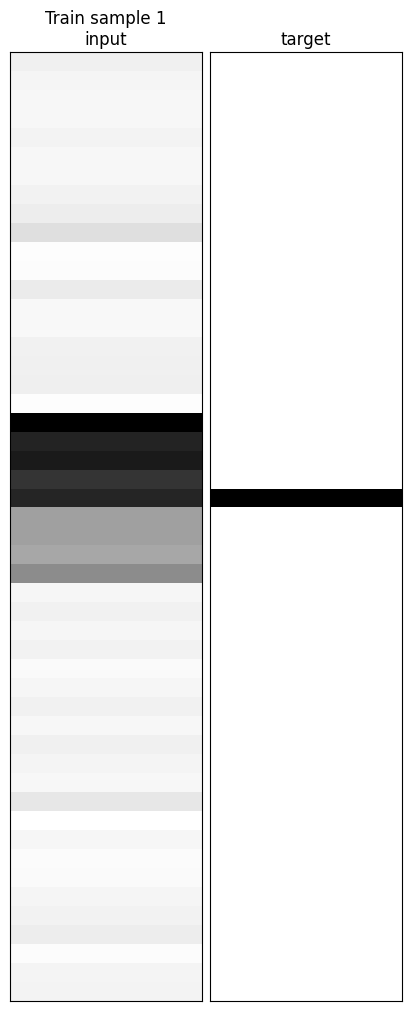

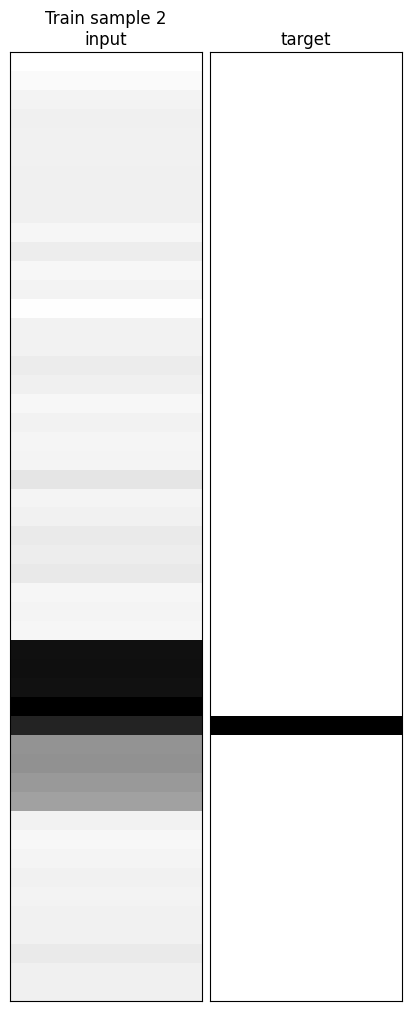

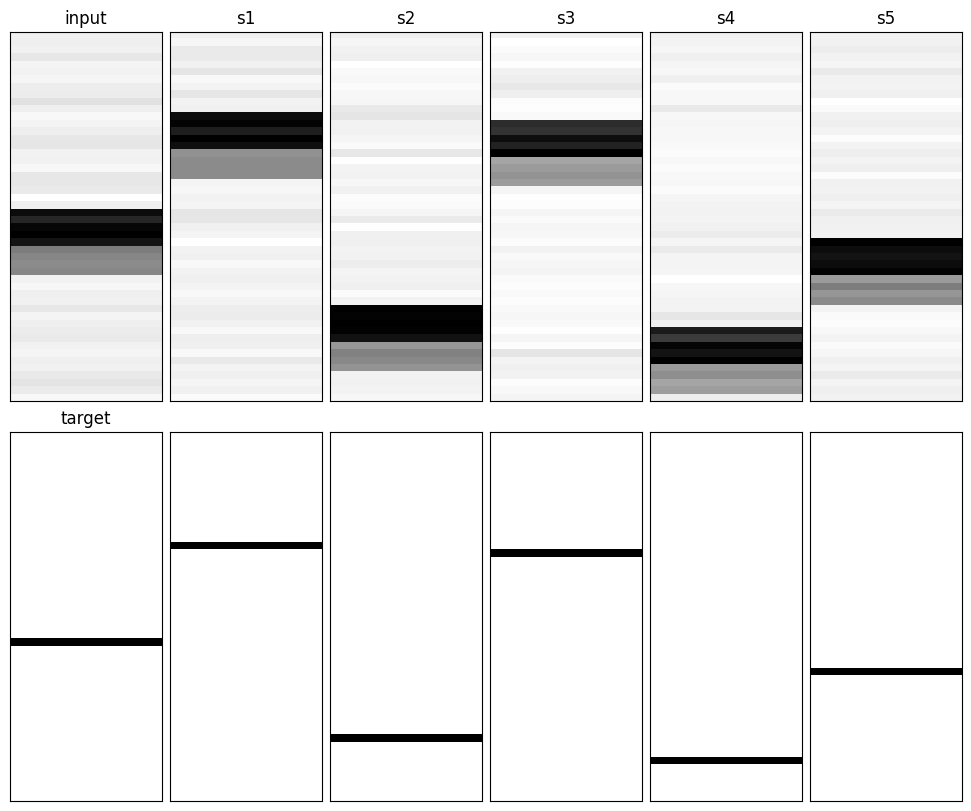

In [9]:
# ============================================
# Synthetic 1D "tree" dataset saved under ./data/
# Torchvision-like root/subfolder structure
#
# Folder structure:
#   ./data/
#       tree1d_vertical_v1/
#           processed/
#               train.pt
#               test.pt
#               meta.pt
# ============================================

from pathlib import Path
import torch
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


# =========================================================
# 1) Data generation
# =========================================================
def generate_tree_split(
    num_samples: int,
    length: int,
    leaf_len: int,
    trunk_len: int,
    leaf_value: float,
    trunk_value: float,
    noise_std: float,
    seed: int,
):
    """
    Generate one split of the synthetic vertical 1D tree dataset.

    Returns a dict with:
        x_img           : [B, 1, N, 1]
        target_map_img  : [B, 1, N, 1]
        target_map      : [B, N]
        center_index    : [B]
        start_index     : [B]
    """
    tree_width = leaf_len + trunk_len
    if tree_width % 2 == 0:
        raise ValueError(
            f"leaf_len + trunk_len must be odd so the center is unambiguous. "
            f"Got {leaf_len} + {trunk_len} = {tree_width}."
        )

    if tree_width > length:
        raise ValueError(
            f"Tree width ({tree_width}) cannot exceed signal length ({length})."
        )

    g = torch.Generator().manual_seed(seed)

    # Vertical image-like inputs: [B, C=1, H=length, W=1]
    x_img = torch.randn(num_samples, 1, length, 1, generator=g) * noise_std

    # Vertical image-like target maps: [B, 1, length, 1]
    target_map_img = torch.zeros(num_samples, 1, length, 1)

    # Flat target maps: [B, length]
    target_map = torch.zeros(num_samples, length)

    center_index = torch.zeros(num_samples, dtype=torch.long)
    start_index = torch.zeros(num_samples, dtype=torch.long)

    max_start = length - tree_width
    starts = torch.randint(
        low=0,
        high=max_start + 1,
        size=(num_samples,),
        generator=g,
    )

    for i, start in enumerate(starts):
        start = int(start.item())

        leaf_start = start
        leaf_end = start + leaf_len

        trunk_start = leaf_end
        trunk_end = trunk_start + trunk_len

        # Write the pattern into the vertical column
        x_img[i, 0, leaf_start:leaf_end, 0] += leaf_value
        x_img[i, 0, trunk_start:trunk_end, 0] += trunk_value

        center = start + tree_width // 2
        target_map_img[i, 0, center, 0] = 1.0
        target_map[i, center] = 1.0
        center_index[i] = center
        start_index[i] = start

    return {
        "x_img": x_img,                        # [B, 1, N, 1]
        "target_map_img": target_map_img,      # [B, 1, N, 1]
        "target_map": target_map,              # [B, N]
        "center_index": center_index,          # [B]
        "start_index": start_index,            # [B]
    }


def save_tree_dataset(
    root: str = "./data",
    dataset_name: str = "tree1d_vertical",
    train_size: int = 2000,
    test_size: int = 400,
    length: int = 50,
    leaf_len: int = 5,
    trunk_len: int = 4,   # total width = 9
    leaf_value: float = 1.0,
    trunk_value: float = 0.5,
    noise_std: float = 0.05,
    train_seed: int = 0,
    test_seed: int = 1,
    overwrite: bool = False,
):
    """
    Create the dataset on disk under:
        root/dataset_name/processed/
    """
    root = Path(root)
    dataset_dir = root / dataset_name
    processed_dir = dataset_dir / "processed"

    processed_dir.mkdir(parents=True, exist_ok=True)

    train_path = processed_dir / "train.pt"
    test_path = processed_dir / "test.pt"
    meta_path = processed_dir / "meta.pt"

    if not overwrite and train_path.exists() and test_path.exists() and meta_path.exists():
        print(f"Dataset already exists at: {dataset_dir.resolve()}")
        return dataset_dir

    train_data = generate_tree_split(
        num_samples=train_size,
        length=length,
        leaf_len=leaf_len,
        trunk_len=trunk_len,
        leaf_value=leaf_value,
        trunk_value=trunk_value,
        noise_std=noise_std,
        seed=train_seed,
    )

    test_data = generate_tree_split(
        num_samples=test_size,
        length=length,
        leaf_len=leaf_len,
        trunk_len=trunk_len,
        leaf_value=leaf_value,
        trunk_value=trunk_value,
        noise_std=noise_std,
        seed=test_seed,
    )

    meta = {
        "dataset_name": dataset_name,
        "length": length,
        "leaf_len": leaf_len,
        "trunk_len": trunk_len,
        "tree_width": leaf_len + trunk_len,
        "leaf_value": leaf_value,
        "trunk_value": trunk_value,
        "noise_std": noise_std,
        "train_size": train_size,
        "test_size": test_size,
        "train_seed": train_seed,
        "test_seed": test_seed,
        "shape_per_sample": [1, length, 1],  # [C, H, W]
        "task": "center localization with a target response map",
    }

    torch.save(train_data, train_path)
    torch.save(test_data, test_path)
    torch.save(meta, meta_path)

    print(f"Saved dataset to: {dataset_dir.resolve()}")
    print(f"  - {train_path.name}")
    print(f"  - {test_path.name}")
    print(f"  - {meta_path.name}")

    return dataset_dir


# =========================================================
# 2) Disk-backed Dataset
# =========================================================
class Tree1DImageDiskDataset(Dataset):
    """
    Loads the saved dataset from disk.

    Sample output:
        {
            "x_img": [1, N, 1],
            "target_map_img": [1, N, 1],
            "target_map": [N],
            "center_index": scalar
        }
    """

    def __init__(
        self,
        root: str = "./data",
        dataset_name: str = "tree1d_vertical_v1",
        train: bool = True,
        create_if_missing: bool = True,
        **generation_kwargs,
    ):
        super().__init__()

        self.root = Path(root)
        self.dataset_name = dataset_name
        self.dataset_dir = self.root / self.dataset_name
        self.processed_dir = self.dataset_dir / "processed"

        train_path = self.processed_dir / "train.pt"
        test_path = self.processed_dir / "test.pt"
        meta_path = self.processed_dir / "meta.pt"

        if create_if_missing and not (train_path.exists() and test_path.exists() and meta_path.exists()):
            save_tree_dataset(
                root=root,
                dataset_name=dataset_name,
                **generation_kwargs,
            )

        if not train_path.exists() or not test_path.exists() or not meta_path.exists():
            raise FileNotFoundError(
                f"Dataset files not found under {self.processed_dir.resolve()}.\n"
                f"Either set create_if_missing=True or generate them first."
            )

        split_path = train_path if train else test_path
        self.data = torch.load(split_path)
        self.meta = torch.load(meta_path)
        self.train = train

    def __len__(self):
        return self.data["x_img"].shape[0]

    def __getitem__(self, idx):
        return {
            "x_img": self.data["x_img"][idx],                    # [1, N, 1]
            "target_map_img": self.data["target_map_img"][idx], # [1, N, 1]
            "target_map": self.data["target_map"][idx],         # [N]
            "center_index": self.data["center_index"][idx],     # scalar
        }


# =========================================================
# 3) Visualization
# =========================================================
def show_sample_as_image(sample, title="Sample"):
    """
    Visualize one sample as a vertical grayscale image.
    No guide lines.
    """
    x_img = sample["x_img"][0].numpy()                 # [N, 1]
    target_img = sample["target_map_img"][0].numpy()  # [N, 1]

    fig, axes = plt.subplots(1, 2, figsize=(4, 10), constrained_layout=True)

    axes[0].imshow(
        x_img,
        aspect="auto",
        interpolation="nearest",
        cmap="Greys",
        origin="upper",
    )
    axes[0].set_title(f"{title}\ninput")
    axes[0].set_xticks([])
    axes[0].set_yticks([])

    axes[1].imshow(
        target_img,
        aspect="auto",
        interpolation="nearest",
        cmap="Greys",
        origin="upper",
        vmin=0,
        vmax=1,
    )
    axes[1].set_title("target")
    axes[1].set_xticks([])
    axes[1].set_yticks([])

    plt.show()


def show_batch_as_images(batch, n_show=8, title="Batch"):
    """
    Show a batch of vertical image strips.
    Top row: inputs
    Bottom row: targets
    """
    x = batch["x_img"][:n_show]                 # [B, 1, N, 1]
    target = batch["target_map_img"][:n_show]   # [B, 1, N, 1]

    fig, axes = plt.subplots(
        2,
        n_show,
        figsize=(1.6 * n_show, 8),
        constrained_layout=True
    )

    if n_show == 1:
        axes = axes.reshape(2, 1)

    for i in range(n_show):
        xi = x[i, 0].numpy()     # [N, 1]
        ti = target[i, 0].numpy()  # [N, 1]

        axes[0, i].imshow(
            xi,
            aspect="auto",
            interpolation="nearest",
            cmap="Greys",
            origin="upper",
        )
        axes[0, i].set_xticks([])
        axes[0, i].set_yticks([])
        axes[0, i].set_title("input" if i == 0 else f"s{i}")

        axes[1, i].imshow(
            ti,
            aspect="auto",
            interpolation="nearest",
            cmap="Greys",
            origin="upper",
            vmin=0,
            vmax=1,
        )
        axes[1, i].set_xticks([])
        axes[1, i].set_yticks([])
        axes[1, i].set_title("target" if i == 0 else "")

    plt.show()


# =========================================================
# 4) Create dataset on disk
# =========================================================
dataset_dir = save_tree_dataset(
    root="./data",
    dataset_name="tree1d_vertical",
    train_size=2000,
    test_size=400,
    length=50,
    leaf_len=5,
    trunk_len=4,
    leaf_value=1.0,
    trunk_value=0.5,
    noise_std=0.05,
    train_seed=0,
    test_seed=1,
    overwrite=False,
)

# =========================================================
# 5) Load from disk
# =========================================================
train_dataset = Tree1DImageDiskDataset(
    root="./data",
    dataset_name="tree1d_vertical",
    train=True,
    create_if_missing=False,
)

test_dataset = Tree1DImageDiskDataset(
    root="./data",
    dataset_name="tree1d_vertical",
    train=False,
    create_if_missing=False,
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

# =========================================================
# 6) Check shapes
# =========================================================
batch = next(iter(train_loader))
print("Dataset folder       :", dataset_dir.resolve())
print("x_img shape          :", batch["x_img"].shape)          # [B, 1, 50, 1]
print("target_map_img shape :", batch["target_map_img"].shape) # [B, 1, 50, 1]
print("target_map shape     :", batch["target_map"].shape)     # [B, 50]
print("center_index shape   :", batch["center_index"].shape)   # [B]

# =========================================================
# 7) Visualize
# =========================================================
for i in range(3):
    show_sample_as_image(train_dataset[i], title=f"Train sample {i}")

batch = next(iter(train_loader))
show_batch_as_images(batch, n_show=6, title="Training batch")